## Business Context

This project analyzes operational data from a High-Performance Computing (HPC) cluster. The system is managed by a job scheduler (Slurm) and serves multiple users submitting computational workloads. Some jobs use CPUs only, while others use GPUs for accelerated workloads such as AI/ML training.

In this context, the compute platform behaves like an internal “infrastructure-as-a-service” product. Its goals are:

- Deliver compute jobs reliably

- Minimize user waiting time

- Use expensive GPU resources efficiently

- Maintain system stability under variable demand

Users submit jobs. The scheduler queues and allocates resources. GPU telemetry records actual hardware utilization and energy usage during execution.

The central operational question becomes:

**How do we measure platform performance in a way that is stable, reliable, unbiased, and resistant to manipulation?**

This is where metric validity becomes critical.

### Why Metric Validity Matters Here

Operational metrics in infrastructure systems are often:

- Heavy-tailed

- Highly segmented (by job size, partition, workload type)

- Subject to drift over time

- Sensitive to rare congestion events

- Influenced by missing data

- Choosing the wrong metric can lead to:

- False conclusions

- Misleading improvements

- Gaming behavior

- Masked inefficiencies

Therefore, this project selects one North Star metric and two Guardrail metrics, then systematically evaluates their validity across:

- **Missingness, Segmentation bias, Drift, Stability, Reliability, Sensitivity, CUPED variance reduction**

## Dataset

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path

RAW_DIR = Path("/Users/newuser/.cache/kagglehub/datasets/skylarkphantom/mit-datacenter-challenge-data/versions/1")
SCHED_CSV = RAW_DIR / "scheduler_data.csv"
DCGM_CSV  = RAW_DIR / "dcgm.csv"

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: /Users/newuser/Desktop/Victoria/Projects_2025/metric-validation-playbook
Data directory: /Users/newuser/Desktop/Victoria/Projects_2025/metric-validation-playbook/data


**Dataset Description**

This project analyzes operational and efficiency metrics from a high-performance computing (HPC) environment using two complementary datasets:

- Scheduler Accounting Data (scheduler_data.csv)

- GPU Telemetry Data (dcgm.csv)

Together, they provide both job-level operational information and GPU-level resource utilization measurements, enabling analysis of performance, reliability, congestion, and efficiency.

1. Scheduler Accounting Dataset (scheduler_data.csv)

The scheduler dataset contains job-level accounting records generated by the Slurm workload manager. Each row represents a single job submission and contains metadata describing its lifecycle and resource allocation.

**Granularity:** One row per job (id_job is the natural primary key).

**Key information contained**

- Lifecycle timestamps

time_submit, time_start, time_end, time_eligible

- Resource requests and allocations

cpus_req, nodes_alloc, mem_req, gres_req, gres_alloc

- Job classification

partition, job_type, state

- Execution outcomes

exit_code, derived_ec


Because this table is job-granular, it forms the foundation for operational KPIs such as latency, congestion, and service stability.

2. GPU Telemetry Dataset (dcgm.csv)

The DCGM dataset contains GPU-level monitoring data collected using NVIDIA’s Data Center GPU Manager (DCGM). It captures performance and energy measurements during job execution.

Unlike the scheduler dataset, this table is not job-granular.

**Granularity:** One row per job × GPU instance (potentially multiple rows per job). If a job runs on multiple GPUs or nodes, it produces multiple telemetry records.

**Key information contained**

- Compute utilization

smutilization_pct_avg, memoryutilization_pct_avg

- Energy and power

energyconsumed_joules, powerusage_watts_avg

- Execution duration

totalexecutiontime_sec

- Hardware identifiers

Node, gpu_id


Because telemetry is collected at the GPU-instance level, it must be aggregated to job-level before combining with scheduler data.

**Relationship Between the Two Datasets**
- scheduler_data describes what was requested and how the job was scheduled.

- dcgm describes how the GPU hardware was actually used during execution.

In [2]:

sched_cols = pd.read_csv(SCHED_CSV, nrows=0).columns.tolist()
dcgm_cols  = pd.read_csv(DCGM_CSV, nrows=0).columns.tolist()

print("scheduler_data.csv columns:\n", sched_cols)
print("\ndcgm.csv columns:\n", dcgm_cols)

sched_raw = pd.read_csv(SCHED_CSV, low_memory=False)
dcgm_raw  = pd.read_csv(DCGM_CSV,  low_memory=False)

print("sched_raw:", sched_raw.shape)
print("dcgm_raw:", dcgm_raw.shape)

sched_raw.head()

scheduler_data.csv columns:
 ['id_array_job', 'id_array_task', 'id_user', 'kill_requid', 'nodes_alloc', 'nodelist', 'cpus_req', 'derived_ec', 'exit_code', 'gres_req', 'gres_alloc', 'gres_used', 'array_max_tasks', 'array_task_pending', 'constraints', 'flags', 'mem_req', 'partition', 'priority', 'state', 'timelimit', 'time_submit', 'time_eligible', 'time_start', 'time_end', 'time_suspended', 'track_steps', 'tres_alloc', 'tres_req', 'job_type', 'id_job']

dcgm.csv columns:
 ['Node', 'avgmemoryutilization_pct', 'avgsmutilization_pct', 'energyconsumed_joules', 'gpu_id', 'maxgpumemoryused_bytes', 'memoryutilization_pct_avg', 'memoryutilization_pct_max', 'memoryutilization_pct_min', 'pcierxbandwidth_megabytes_avg', 'pcierxbandwidth_megabytes_max', 'pcierxbandwidth_megabytes_min', 'pcietxbandwidth_megabytes_avg', 'pcietxbandwidth_megabytes_max', 'pcietxbandwidth_megabytes_min', 'powerusage_watts_avg', 'powerusage_watts_max', 'powerusage_watts_min', 'smutilization_pct_avg', 'smutilization_pct_m

,id_array_job,id_array_task,id_user,kill_requid,nodes_alloc,nodelist,cpus_req,derived_ec,exit_code,gres_req,gres_alloc,gres_used,array_max_tasks,array_task_pending,constraints,flags,mem_req,partition,priority,state,timelimit,time_submit,time_eligible,time_start,time_end,time_suspended,track_steps,tres_alloc,tres_req,job_type,id_job
0,41161693674,4595979483,66088413977,51671871839,0,[],1,0,256,NaN,NaN,NaN,0,0,xeon-g6,0,9223372036854780808,gpu,19995,5,720,3014,3014,3014,3014,-1,0,NaN,"1=1,2=5000,4=1,5=1,1002=2",OTHER,13715936505
1,41161693674,4595979483,66088413977,51671871839,1,['r2684277-n303509'],1,0,0,gpu:volta:2,gpu:2,NaN,0,0,xeon-g6,2,9223372036854785408,gaia,19995,3,4294967295,3022,3022,3022,3025,-1,0,"1=1,2=9600,4=1,5=1,1002=2","1=1,2=9600,4=1,5=1,1002=2",OTHER,25780056187
2,41161693674,4595979483,16176946191,51671871839,1,['r5198790-n347934'],4,32512,32512,gpu:volta:1,gpu:1,NaN,0,0,xeon-g6,4,9223372036854785408,gaia,110012,5,4294967295,5682,5682,5683,5684,-1,0,"1=4,2=38400,4=1,5=4,1002=1","1=4,2=38400,4=1,5=4,1002=1",OTHER,53722449986
3,41161693674,4595979483,16176946191,16176946191,1,['r3541344-n655125'],4,0,0,gpu:volta:1,gpu:1,NaN,0,0,xeon-e5,4,9223372036854780808,gpu,110023,4,720,34467,34467,34468,34548,-1,0,"1=4,2=20000,4=1,5=4,1002=1","1=4,2=20000,4=1,5=4,1002=1",OTHER,19989272070
4,41161693674,4595979483,16176946191,16176946191,1,['r3541344-n655125'],4,0,0,gpu:volta:1,gpu:1,NaN,0,0,xeon-e5,4,9223372036854780808,gpu,110006,4,720,34596,34596,34596,35108,-1,0,"1=4,2=20000,4=1,5=4,1002=1","1=4,2=20000,4=1,5=4,1002=1",OTHER,49220239266


these are not UTC timestamps.

What you’re seeing are relative time counters (seconds since the start of the trace / logging epoch), not wall-clock time.

**For scheduler data:**

id_job — Unique job ID (primary key)

id_array_job — Parent job ID if this is part of a job array

id_array_task — Task index inside a job array

id_user — Anonymized user ID (customer / internal team proxy)

job_type — Type/class of job (batch, interactive, etc. depending on system)

partition — Queue/partition used (different hardware pools or policies)

state — Final job state (COMPLETED, FAILED, CANCELLED, etc.)

time_submit — When user submitted the job

time_eligible — When job became eligible to run (passed constraints)

time_start — When job actually started running

time_end — When job finished

time_suspended — Time spent suspended (if preempted/paused)

timelimit — Max allowed runtime requested or enforced

cpus_req — Number of CPUs requested

nodes_alloc — Number of nodes allocated

mem_req — Memory requested

gres_req — Generic resources requested (e.g., GPUs) (string-encoded)

gres_alloc — Generic resources allocated

gres_used — Generic resources actually used

tres_req — Trackable resources requested (CPU, memory, GPU, etc.) (encoded)

tres_alloc — Trackable resources allocated

exit_code — Job exit status (success/failure reason)

derived_ec — Derived/normalized exit code

kill_requid — Reason for kill (if terminated)

flags — Scheduler flags

constraints — Constraints requested (e.g., node types)

priority — Scheduling priority

track_steps — Whether steps were tracked

**For dcgm data:**

id_job — Job ID (join key to scheduler)

Node — Compute node name

gpu_id — GPU index on that node

Utilization (how busy the GPU was)

avgsmutilization_pct / smutilization_pct_avg — Average SM (compute core) utilization %

smutilization_pct_min / max` — Min/max SM utilization

avgmemoryutilization_pct — Avg GPU memory utilization %

memoryutilization_pct_min / avg / max — Memory usage stats

powerusage_watts_avg / min / max — GPU power draw

energyconsumed_joules — Total energy used by job

totalexecutiontime_sec — GPU execution time measured by DCGM

## EDA

### Scheduler Accounting Dataset

### 1.Duplicated ids 

In [5]:
# Primary keys sanity
print("Unique jobs (scheduler):", sched_raw["id_job"].nunique())
print("Rows (scheduler):", len(sched_raw))

print("Unique jobs (dcgm):", dcgm_raw["id_job"].nunique())
print("Rows (dcgm):", len(dcgm_raw))

# Check duplicates in scheduler by id_job
dup_jobs = sched_raw["id_job"].duplicated().mean()
print("Share duplicated id_job in scheduler:", dup_jobs)

Unique jobs (scheduler): 287069
Rows (scheduler): 287173
Unique jobs (dcgm): 74849
Rows (dcgm): 96893
Share duplicated id_job in scheduler: 0.00036215103787612347


In [6]:
dups = sched_raw[sched_raw.duplicated("id_job", keep=False)].sort_values("id_job")
dups

,id_array_job,id_array_task,id_user,kill_requid,nodes_alloc,nodelist,cpus_req,derived_ec,exit_code,gres_req,gres_alloc,gres_used,array_max_tasks,array_task_pending,constraints,flags,mem_req,partition,priority,state,timelimit,time_submit,time_eligible,time_start,time_end,time_suspended,track_steps,tres_alloc,tres_req,job_type,id_job
198343,41161693674,4595979483,25051342948,51671871839,1,['r4099734-n200569'],4,0,0,gpu:volta:1,gpu:1,NaN,0,0,xeon-g6,4,9223372036854784308,normal,10392,7,4294967295,18638183,18638183,18638184,18654917,-1,0,"1=4,2=34000,4=1,5=4,1002=1","1=4,2=34000,4=1,5=4,1002=1",LLSUB:BATCH,1284123605
198624,41161693674,4595979483,25051342948,25051342948,1,['r7141590-n200569'],4,0,0,gpu:volta:1,gpu:1,NaN,0,0,xeon-g6,4,9223372036854784308,normal,10392,4,4294967295,18654917,18655038,18655045,18709144,-1,0,"1=4,2=34000,4=1,5=4,1002=1","1=4,2=34000,4=1,5=4,1002=1",LLSUB:BATCH,1284123605
257236,41161693674,4595979483,50858793592,51671871839,1,['r7753495-n772143'],20,0,0,gpu:volta:1,gpu:1,NaN,0,0,xeon-g6,12,9223372036854784308,normal,10226,3,4294967295,26687821,26687942,26687948,26738731,-1,0,"1=20,2=170000,4=1,5=20,1002=1","1=20,2=170000,4=1,5=20,1002=1",OTHER,1369901951
257234,41161693674,4595979483,50858793592,51671871839,1,['r4683026-n772143'],20,0,0,gpu:volta:1,gpu:1,NaN,0,0,xeon-g6,4,9223372036854784308,normal,10226,7,4294967295,26687063,26687063,26687069,26687821,-1,0,"1=20,2=170000,4=1,5=20,1002=1","1=20,2=170000,4=1,5=20,1002=1",OTHER,1369901951
224949,41161693674,4595979483,66088413977,51671871839,1,['r7419443-n303509'],20,0,256,gpu:volta:1,gpu:1,NaN,0,0,xeon-g6,4,9223372036854784308,normal,110177,7,1440,23174186,23174186,23174187,23193144,-1,0,"1=20,2=170000,3=18446744073709551614,4=1,5=20,...","1=20,2=170000,4=1,5=20,1002=1",OTHER,3786120982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283087,41161693674,4595979483,60326585414,51671871839,1,['r4099734-n772143'],1,0,256,gpu:volta:1,gpu:1,NaN,0,0,xeon-g6,12,9223372036854784308,normal,10388,5,4294967295,31398384,31398505,31398521,31799569,-1,0,"1=1,2=8500,3=18446744073709551614,4=1,5=1,1002=1","1=1,2=8500,4=1,5=1,1002=1",LLSUB:BATCH,62005548167
3073,41161693674,4595979483,66088413977,51671871839,32,"['r8473362-n882168', 'r492024-n882168', 'r9988...",64,256,0,gpu:volta:64,gpu:64,NaN,0,0,xeon-g6,4,9223372036854785408,gaia,10038,3,4294967295,2492876,2492997,2497645,2498198,-1,0,"1=64,2=614400,4=32,5=64,1002=64","1=64,2=614400,4=32,5=64,1002=64",OTHER,62134470600
3056,41161693674,4595979483,66088413977,51671871839,32,"['r8024255-n882168', 'r8473362-n882168', 'r492...",64,0,0,gpu:volta:64,gpu:64,NaN,0,0,xeon-g6,4,9223372036854785408,gaia,10038,7,4294967295,2490338,2490338,2490344,2492872,-1,0,"1=64,2=614400,3=18446744073709551614,4=32,5=64...","1=64,2=614400,4=32,5=64,1002=64",OTHER,62134470600
257237,41161693674,4595979483,50858793592,51671871839,1,['r7753495-n772143'],20,0,0,gpu:volta:1,gpu:1,NaN,0,0,xeon-g6,12,9223372036854784308,normal,10226,3,4294967295,26687821,26687942,26687948,26754780,-1,0,"1=20,2=170000,4=1,5=20,1002=1","1=20,2=170000,4=1,5=20,1002=1",OTHER,66569726341


As seen above, the schedule dataset contains duplicated id_job rows. Moreover, the rows are not identical. As mentioned in the initial paper of the dataset, we should:
- Prefer state == 3
- Else take row with max time_end

This seems to mean that we keep the row that represents the final execution outcome.

In [7]:
sched_raw["state"].value_counts()

state
3       108911
4       103576
5        70432
6         3768
1          183
11         159
7           89
1024        41
0           14
Name: count, dtype: int64

In [8]:
def pick_final_record(group):
    g3 = group[group["state"] == 3]
    if len(g3) > 0:
        return g3.loc[[g3["time_end"].idxmax()]]
    return group.loc[[group["time_end"].idxmax()]]

sched_canon = (
    sched_raw
    .groupby("id_job", group_keys=True)
    .apply(pick_final_record)
    .reset_index(level=0)     # bring id_job from index -> column
    .reset_index(drop=True)   # drop leftover row index
)

assert sched_canon["id_job"].is_unique

In [9]:
sched_dedup = sched_canon.copy()

sched_dedup.to_csv(INTERIM_DIR / "sched_dedup.csv", index=False)

print("Saved to:", INTERIM_DIR / "sched_dedup.csv")
print("Shape:", sched_dedup.shape)

Saved to: /Users/newuser/Desktop/Victoria/Projects_2025/metric-validation-playbook/data/interim/sched_dedup.csv
Shape: (287069, 31)


### 2. Main columns
The step inspects the dataset schema and basic distributions of key categorical variables to ensure the data types and main fields are consistent with expectations before further analysis. It also verifies that the canonical dataset contains one row per job and that resource request fields are valid.

In [10]:
core_cols = [
    "id_job","state","partition","job_type",
    "time_submit","time_start","time_end","time_eligible",
    "cpus_req","nodes_alloc","mem_req",
    "exit_code","derived_ec"
]
print(sched_canon[core_cols].dtypes)
print("\nState counts:\n", sched_canon["state"].value_counts().head(10))
print("\nPartition counts:\n", sched_canon["partition"].value_counts())
print("\ncpus_req zeros share:", (sched_canon["cpus_req"] == 0).mean())

id_job            int64
state             int64
partition           str
job_type            str
time_submit       int64
time_start        int64
time_end          int64
time_eligible     int64
cpus_req          int64
nodes_alloc       int64
mem_req          uint64
exit_code         int64
derived_ec        int64
dtype: object

State counts:
 state
3       108911
4       103576
5        70432
6         3768
1          179
11         159
7           27
0           14
1024         3
Name: count, dtype: int64

Partition counts:
 partition
gpu           141339
normal        115748
gpu,normal     19603
gaia           10374
test               5
Name: count, dtype: int64

cpus_req zeros share: 0.0


All key fields appear in expected numeric or string formats, and no invalid values are observed in cpus_req. The distribution of scheduler states shows that several different final job states are present, indicating that not all submitted jobs successfully complete. The workload is primarily distributed between the gpu and normal partitions, which together account for the large majority of jobs.

### 3. Time elements

In [11]:
df = sched_canon.copy()

time_cols = ["time_submit","time_start","time_end","time_eligible","time_suspended"]
for c in time_cols:
    if c in df.columns:
        df.loc[df[c] < 0, c] = np.nan

df["queue_wait_s"] = df["time_start"] - df["time_submit"]
df["runtime_s"] = df["time_end"] - df["time_start"]
df["turnaround_s"] = df["time_end"] - df["time_submit"]

# executed jobs: valid submit, start, end and sane deltas
exec_df = df[
    df["time_submit"].notna() &
    df["time_start"].notna() &
    df["time_end"].notna() &
    (df["queue_wait_s"] >= 0) &
    (df["runtime_s"] >= 0) &
    (df["turnaround_s"] >= 0)
].copy()

print("Executed jobs:", len(exec_df), " / ", len(df), " (share:", len(exec_df)/len(df), ")")

Executed jobs: 217638  /  287069  (share: 0.7581382873107162 )


In [12]:
tmp = df.copy()
tmp["is_executed"] = (
    tmp["time_submit"].notna() &
    tmp["time_start"].notna() &
    tmp["time_end"].notna()
)
tmp.groupby("partition")["is_executed"].mean().sort_values(ascending=False)

partition
test          1.000000
gaia          0.948911
normal        0.917813
gpu           0.718514
gpu,normal    0.000000
Name: is_executed, dtype: float64

Approximately 75.8% of jobs satisfy the executed-job criteria, meaning that about one quarter of scheduler entries correspond to jobs that never started or did not complete normally. Execution rates differ significantly by partition: jobs in the normal and gaia partitions almost always run, while the gpu partition shows lower execution rates. The gpu,normal partition appears to contain only jobs that never reached execution, suggesting it represents scheduling requests that were never dispatched.

The next step creates a relative time axis in weeks based on job submission times in order to analyze temporal trends in system performance and workload characteristics.

In [13]:
t0 = exec_df["time_submit"].min()
exec_df["t_rel_week"] = ((exec_df["time_submit"] - t0) // (86400*7)).astype(int)

print("Weeks covered:", exec_df["t_rel_week"].min(), "→", exec_df["t_rel_week"].max())
exec_df["t_rel_week"].value_counts().sort_index().head(10)

Weeks covered: 0 → 52


t_rel_week
0    962
1    801
2    589
3    304
4    539
5    315
6    448
7    552
8    477
9    902
Name: count, dtype: int64

The dataset covers approximately 53 weeks of activity, representing roughly one year of scheduler operation. Weekly job counts vary substantially across the timeline, with some weeks containing relatively few jobs. This variation in weekly volume is important to consider later when evaluating metric stability and reliability, particularly for tail statistics such as the P95 turnaround time.

In [14]:
exec_df[["queue_wait_s","runtime_s","turnaround_s"]].describe(percentiles=[.5,.9,.95,.99])

,queue_wait_s,runtime_s,turnaround_s
count,2.176380e+05,2.176380e+05,2.176380e+05
mean,2.943252e+03,1.189047e+04,1.483372e+04
std,2.091142e+04,6.442350e+04,6.918952e+04
min,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.000000e+00,1.280000e+02,6.330000e+02
90%,3.748000e+03,2.335490e+04,3.254500e+04
95%,9.379450e+03,6.037915e+04,7.185515e+04
99%,5.333519e+04,2.275859e+05,2.592040e+05
max,1.051208e+06,3.174114e+06,3.174114e+06


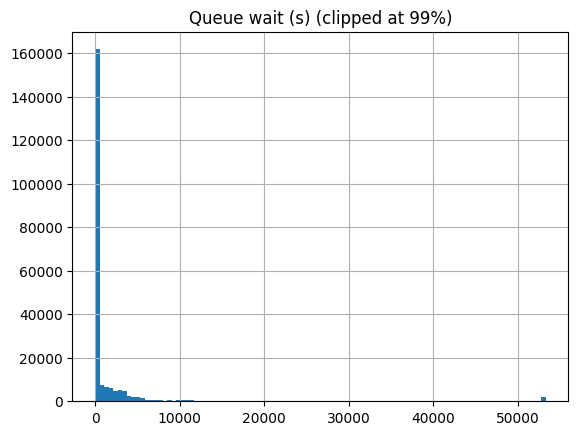

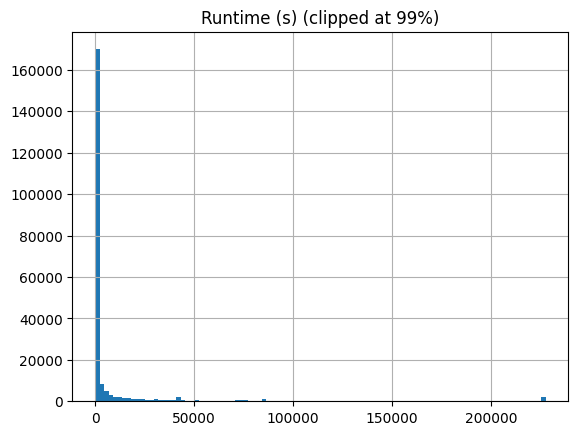

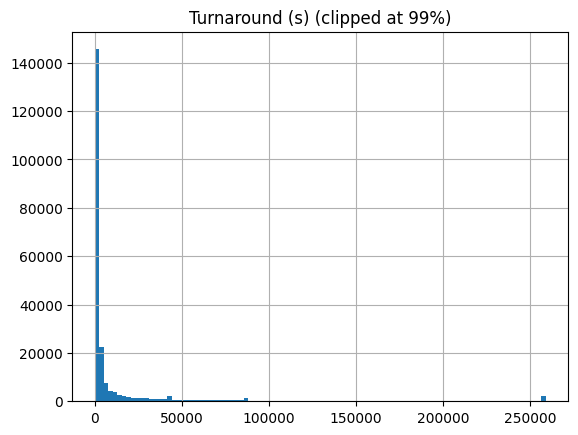

In [15]:

for col, title in [
    ("queue_wait_s","Queue wait (s)"),
    ("runtime_s","Runtime (s)"),
    ("turnaround_s","Turnaround (s)")
]:
    x = exec_df[col].clip(0, exec_df[col].quantile(0.99))
    x.hist(bins=100)
    plt.title(f"{title} (clipped at 99%)")
    plt.show()

All three duration variables show extremely heavy-tailed distributions, with the majority of jobs completing very quickly and a small number of jobs exhibiting extremely long waiting or execution times. Median values are very small compared to the upper percentiles, indicating strong skewness and confirming that mean-based metrics would be misleading. This behavior supports the decision to use percentile-based metrics (such as P95) for performance evaluation.

### 4. Groupping

In [16]:
exec_df["cpus_req_clean"] = exec_df["cpus_req"].replace(0, np.nan)
exec_df["cpu_bucket"] = pd.cut(
    exec_df["cpus_req_clean"],
    bins=[0,1,4,16,64,1e9],
    labels=["1","2-4","5-16","17-64","65+"],
    include_lowest=True
)
exec_df["cpu_bucket"] = exec_df["cpu_bucket"].cat.add_categories(["unknown"]).fillna("unknown")

print("Partition mix:\n", exec_df["partition"].value_counts(normalize=True))
print("\nCPU bucket mix:\n", exec_df["cpu_bucket"].value_counts(normalize=True))
print("\nJob type mix:\n", exec_df["job_type"].value_counts(normalize=True).head(10))

Partition mix:
 partition
normal    0.488127
gpu       0.466619
gaia      0.045231
test      0.000023
Name: proportion, dtype: float64

CPU bucket mix:
 cpu_bucket
1          0.577597
17-64      0.213754
5-16       0.096706
2-4        0.085546
65+        0.026397
unknown    0.000000
Name: proportion, dtype: float64

Job type mix:
 job_type
OTHER                0.784812
LLSUB:BATCH          0.169254
LLSUB:INTERACTIVE    0.034488
LLMAPREDUCE:MAP      0.011446
Name: proportion, dtype: float64


Workload volume is dominated by the normal and gpu partitions, which together represent more than 95% of executed jobs. More than half of all jobs request only a single CPU, while very large jobs requiring more than 64 CPUs represent a small minority of the workload. Additionally, most jobs fall into the generic OTHER job type category, suggesting a heterogeneous mixture of workloads with potentially different performance characteristics. These structural differences indicate that segmentation will be important when evaluating metric bias and stability.

### 5. Queue Wait vs Runtime Relationship

Correlation between queue wait and runtime:
              queue_wait_s  runtime_s
queue_wait_s      1.000000   0.074049
runtime_s         0.074049   1.000000


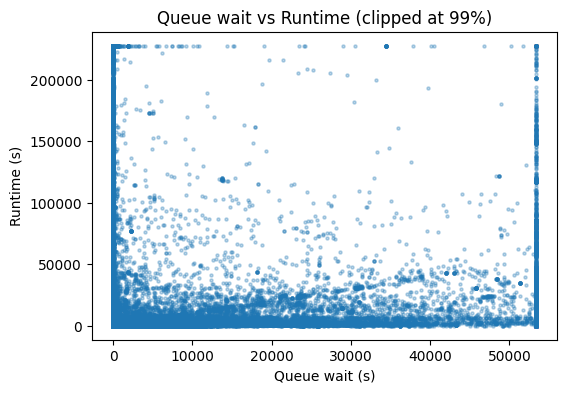

In [17]:
# Correlation between queue wait and runtime
corr = exec_df[["queue_wait_s", "runtime_s"]].corr()
print("Correlation between queue wait and runtime:")
print(corr)

# Scatter plot (clipped to avoid extreme outliers dominating)
q_clip = exec_df["queue_wait_s"].clip(upper=exec_df["queue_wait_s"].quantile(0.99))
r_clip = exec_df["runtime_s"].clip(upper=exec_df["runtime_s"].quantile(0.99))

plt.figure(figsize=(6,4))
plt.scatter(q_clip, r_clip, alpha=0.3, s=5)
plt.xlabel("Queue wait (s)")
plt.ylabel("Runtime (s)")
plt.title("Queue wait vs Runtime (clipped at 99%)")
plt.show()

The correlation between queue wait time and runtime is very weak (≈0.07), indicating that how long a job waits in the queue is largely independent of how long it runs once scheduled. The scatter plot further confirms that most jobs start quickly and run for relatively short durations, while a small number of jobs experience either long waits or long runtimes. This suggests that long turnaround times are primarily driven by rare congestion events rather than inherently long-running jobs.

### 6. Job Size vs Turnaround Time

               count          mean           std  min     50%      90%  \
cpu_bucket                                                               
1           125707.0   7213.857080  56813.327262  0.0   382.0   4843.0   
2-4          18618.0  22351.553604  46626.879120  0.0  5325.0  71852.9   
5-16         21047.0  27484.901649  98301.586186  0.0  2528.0  61888.0   
17-64        46521.0  26959.232841  86276.369192  0.0  1648.0  68859.0   
65+           5745.0  12665.270496  69081.571320  0.0   291.0  19581.4   

                 95%        max  
cpu_bucket                       
1            15322.5  3174114.0  
2-4          80091.9  2543056.0  
5-16        119662.0  1980796.0  
17-64       118775.0  2895388.0  
65+          55475.2  1781779.0  


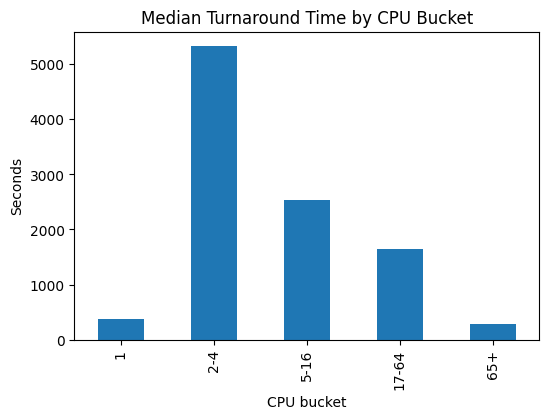

In [18]:
# Turnaround distribution by CPU bucket
size_stats = exec_df.groupby("cpu_bucket")["turnaround_s"].describe(percentiles=[0.5,0.9,0.95])
print(size_stats)

# Median turnaround by CPU bucket
median_turn = exec_df.groupby("cpu_bucket")["turnaround_s"].median().sort_index()

plt.figure(figsize=(6,4))
median_turn.plot(kind="bar")
plt.title("Median Turnaround Time by CPU Bucket")
plt.ylabel("Seconds")
plt.xlabel("CPU bucket")
plt.show()

Turnaround time varies significantly across CPU size buckets, with small jobs (1 CPU) having the lowest median turnaround time and mid-sized jobs (2–4 CPUs) experiencing the highest median delays. Larger jobs show high variability and extremely long tail values, indicating that large resource requests may occasionally encounter scheduling delays. This suggests that job size is an important segmentation dimension and that performance metrics should be analyzed across CPU buckets to avoid masking differences between small and large workloads.

### 7. Weekly Workload Volume and CPU Demand

   t_rel_week  jobs  total_cpus_requested
0           0   962                165938
1           1   801                 69069
2           2   589                 15858
3           3   304                 11582
4           4   539                 19314


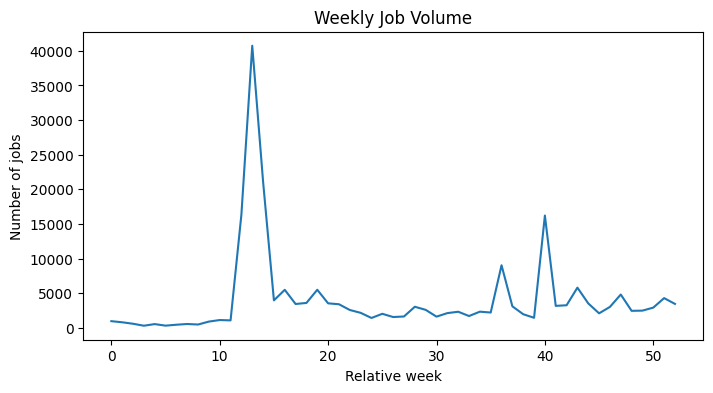

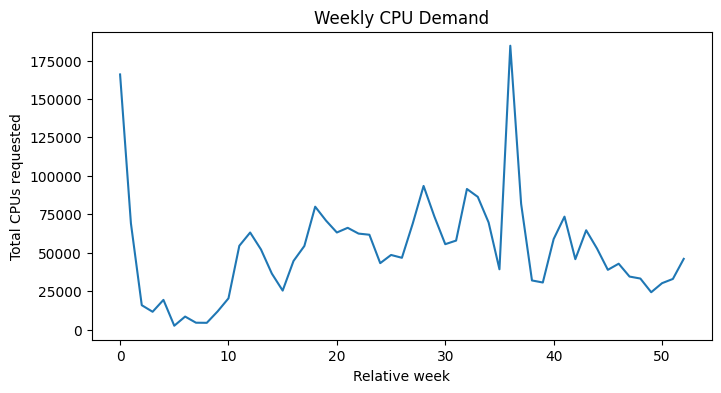

In [19]:
# Weekly job counts
weekly_jobs = exec_df.groupby("t_rel_week").agg(
    jobs=("id_job", "count"),
    total_cpus_requested=("cpus_req", "sum")
).reset_index()

print(weekly_jobs.head())

# Plot weekly job volume
plt.figure(figsize=(8,4))
plt.plot(weekly_jobs["t_rel_week"], weekly_jobs["jobs"])
plt.title("Weekly Job Volume")
plt.xlabel("Relative week")
plt.ylabel("Number of jobs")
plt.show()

# Plot weekly CPU demand
plt.figure(figsize=(8,4))
plt.plot(weekly_jobs["t_rel_week"], weekly_jobs["total_cpus_requested"])
plt.title("Weekly CPU Demand")
plt.xlabel("Relative week")
plt.ylabel("Total CPUs requested")
plt.show()

The weekly workload analysis reveals substantial variability in system demand over time, including several weeks with very large spikes in job volume and CPU demand. These spikes likely correspond to periods of unusually high cluster usage or large batch submissions. 

### GPU Telemetry Dataset

In [20]:
dcgm = dcgm_raw.copy()

num_cols = ["smutilization_pct_avg","memoryutilization_pct_avg","powerusage_watts_avg",
            "energyconsumed_joules","totalexecutiontime_sec"]
for c in num_cols:
    dcgm[c] = pd.to_numeric(dcgm[c], errors="coerce")

dcgm_job = dcgm.groupby("id_job").agg(
    dcgm_rows=("id_job","size"),
    energy_j=("energyconsumed_joules","sum"),
    gpu_exec_s=("totalexecutiontime_sec","sum"),
    sm_util_mean=("smutilization_pct_avg","mean"),
).reset_index()

exec_jobs = exec_df.merge(dcgm_job, on="id_job", how="left")
exec_jobs["gpu_observed"] = exec_jobs["dcgm_rows"].notna()

print("GPU observed share (executed jobs):", exec_jobs["gpu_observed"].mean())

GPU observed share (executed jobs): 0.343864582471811


Approximately 34% of executed jobs have GPU telemetry observations available. This indicates that GPU-based efficiency metrics can only be computed on a subset of the workload. The presence of missing telemetry data must therefore be considered when evaluating GPU utilization metrics, as the observed subset may not perfectly represent all GPU jobs.

## Save datasets

In [21]:
sched_canon.to_parquet(
    INTERIM_DIR / "scheduler_canonical.parquet",
    index=False
)

In [22]:
dcgm_job.to_parquet(
    INTERIM_DIR / "dcgm_job_level.parquet",
    index=False
)